Install and Import Libraries

In [1]:
!pip install shap xgboost -q

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Feature Selection
from sklearn.feature_selection import (
    SelectKBest,
    chi2,
    mutual_info_classif,
    RFE
)

# Models
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Explainable AI
import shap

# Notebook settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries loaded successfully.")

Libraries loaded successfully.


Upload Dataset

In [2]:
from google.colab import files
uploaded = files.upload()

Saving loan_prediction_dataset.csv to loan_prediction_dataset.csv


Load Dataset

In [3]:
import pandas as pd

df = pd.read_csv("loan_prediction_dataset.csv")

print("Dataset Loaded Successfully")
print("\nShape:", df.shape)

df.head()

Dataset Loaded Successfully

Shape: (2000, 7)


,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved
0,56,81788,334,15022,48,Employed,0
1,69,102879,781,21013,24,Self-Employed,1
2,46,58827,779,39687,60,Self-Employed,0
3,32,127188,364,16886,24,Unemployed,0
4,60,25655,307,26256,36,Unemployed,0


Dataset Overview

In [4]:
print("\nDataset Info:\n")
print(df.info())

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nStatistical Summary:\n")
print(df.describe())


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                2000 non-null   int64 
 1   Income             2000 non-null   int64 
 2   Credit_Score       2000 non-null   int64 
 3   Loan_Amount        2000 non-null   int64 
 4   Loan_Term          2000 non-null   int64 
 5   Employment_Status  2000 non-null   object
 6   Loan_Approved      2000 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 109.5+ KB
None

Missing Values:

Age                  0
Income               0
Credit_Score         0
Loan_Amount          0
Loan_Term            0
Employment_Status    0
Loan_Approved        0
dtype: int64

Statistical Summary:

               Age         Income  Credit_Score   Loan_Amount   Loan_Term  \
count  2000.000000    2000.000000   2000.000000   2000.000000  2000.00000   
mean     43.805500   84533.58

Data Cleaning

In [5]:
# Fill numerical columns with median
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical columns with mode
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values handled.")

Missing values handled.


Encode Categorical Features

In [6]:
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("Categorical variables encoded.")

df.head()

Categorical variables encoded.


,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved
0,56,81788,334,15022,48,0,0
1,69,102879,781,21013,24,1,1
2,46,58827,779,39687,60,1,0
3,32,127188,364,16886,24,2,0
4,60,25655,307,26256,36,2,0


Feature and Target Split

In [7]:
TARGET_COLUMN = "Loan_Approved"

X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (2000, 6)
Target Shape: (2000,)


Correlation Heatmap (Filter Method)

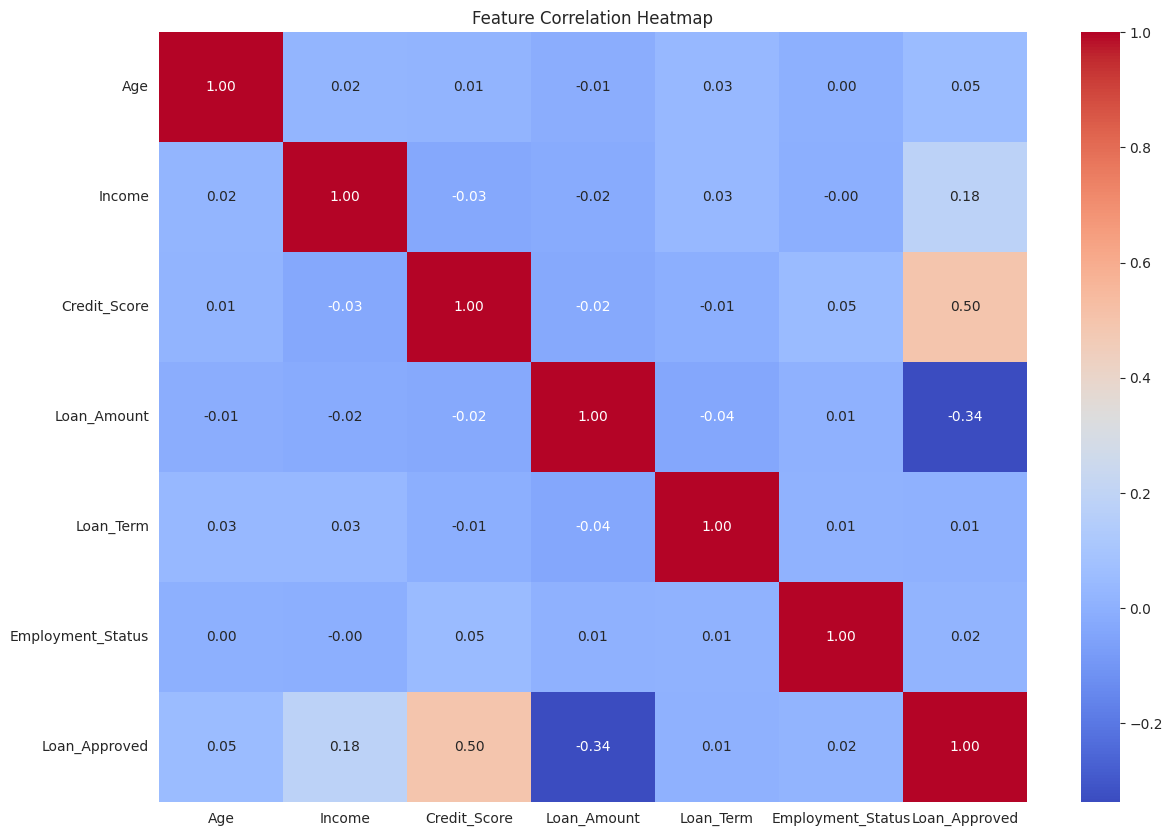

In [8]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

Filter Method Feature Selection

In [9]:
selector = SelectKBest(score_func=mutual_info_classif, k="all")
selector.fit(X, y)

feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "Score": selector.scores_
})

feature_scores = feature_scores.sort_values(
    by="Score",
    ascending=False
)

print(feature_scores)

             Feature     Score
2       Credit_Score  0.192729
3        Loan_Amount  0.098811
1             Income  0.059654
4          Loan_Term  0.006657
5  Employment_Status  0.004801
0                Age  0.002119


Wrapper Method (RFE)

In [10]:
model_rfe = LogisticRegression(max_iter=1000)

rfe = RFE(model_rfe, n_features_to_select=5)

rfe.fit(X, y)

rfe_features = pd.DataFrame({
    "Feature": X.columns,
    "Selected": rfe.support_,
    "Ranking": rfe.ranking_
})

print(rfe_features.sort_values(by="Ranking"))

             Feature  Selected  Ranking
0                Age      True        1
2       Credit_Score      True        1
3        Loan_Amount      True        1
4          Loan_Term      True        1
5  Employment_Status      True        1
1             Income     False        2


Embedded Method (Random Forest)

In [11]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X, y)

embedded_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

embedded_importance = embedded_importance.sort_values(
    by="Importance",
    ascending=False
)

print(embedded_importance)

             Feature  Importance
2       Credit_Score    0.505395
3        Loan_Amount    0.281550
1             Income    0.187807
0                Age    0.016953
4          Loan_Term    0.005025
5  Employment_Status    0.003268


Train/Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (1600, 6)
Test Shape: (400, 6)


Feature Scaling

In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


Logistic Regression Model

In [14]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

print("Accuracy:",
      accuracy_score(y_test, lr_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, lr_pred))

Accuracy: 0.91

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.95      0.95       332
           1       0.75      0.71      0.73        68

    accuracy                           0.91       400
   macro avg       0.85      0.83      0.84       400
weighted avg       0.91      0.91      0.91       400



Logistic Regression Confusion Matrix

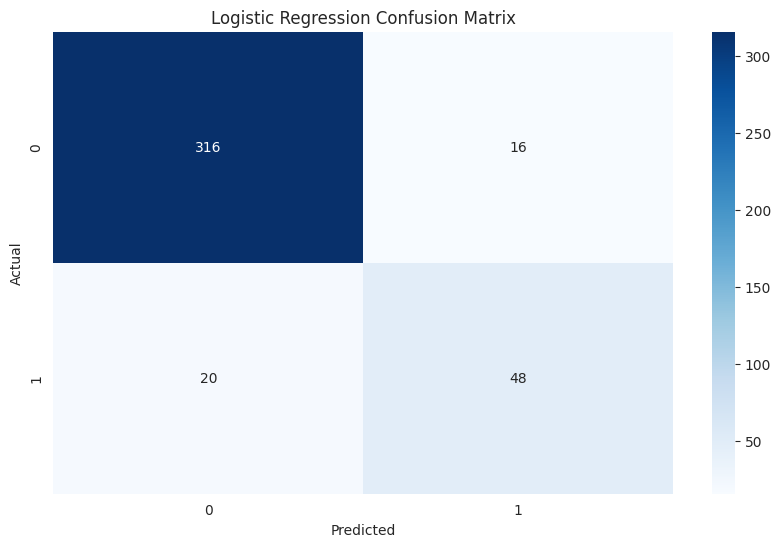

In [24]:
cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Random Forest Model

In [15]:
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, rf_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       332
           1       1.00      1.00      1.00        68

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



Random Forest Confusion Matrix

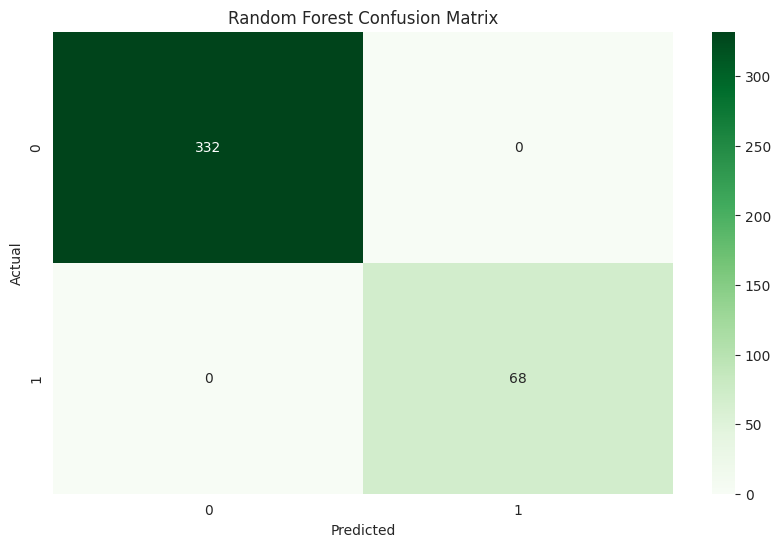

In [25]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

XGBoost Model

In [16]:
xgb_model = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, xgb_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, xgb_pred))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       332
           1       1.00      1.00      1.00        68

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



XGBoost Confusion Matrix

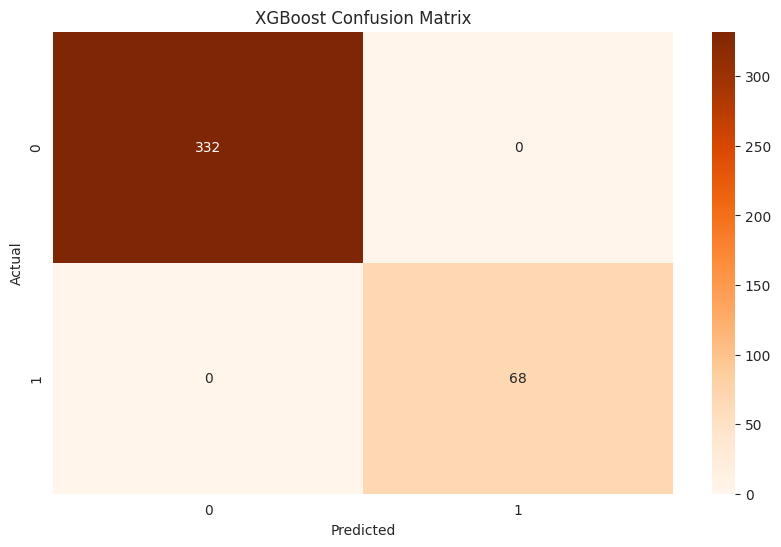

In [26]:
cm = confusion_matrix(y_test, xgb_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Model-Specific Feature Importance

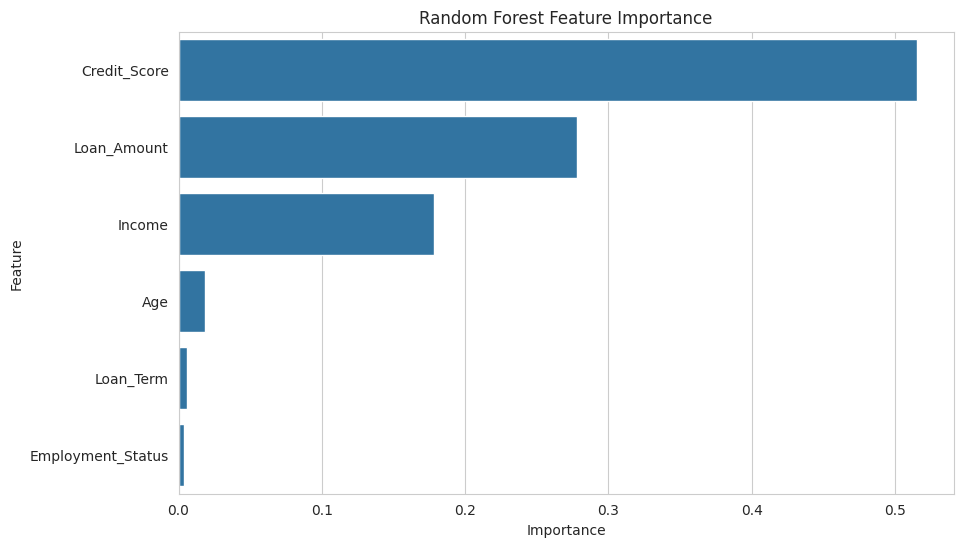

In [17]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df
)

plt.title("Random Forest Feature Importance")
plt.show()

SHAP Analysis

In [18]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

print("SHAP values generated.")

SHAP values generated.


SHAP Summary Plot

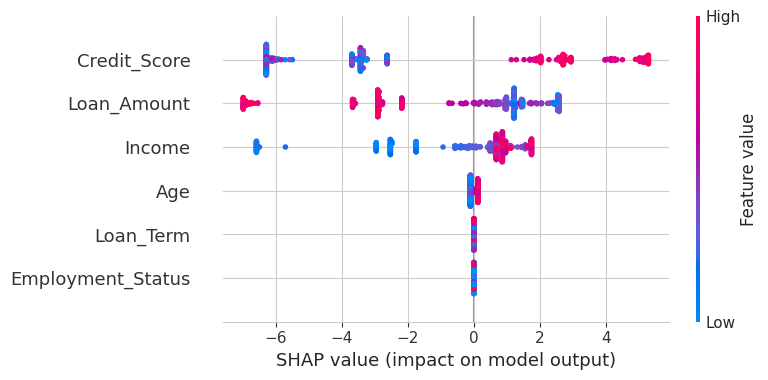

In [19]:
shap.summary_plot(
    shap_values,
    X_test
)

SHAP Bar Plot

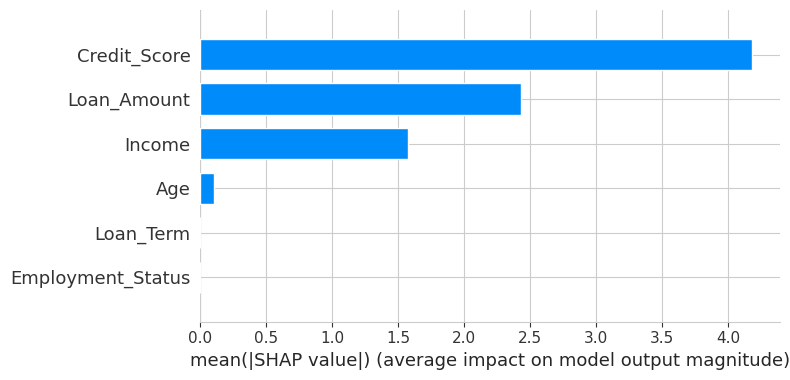

In [20]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

SHAP Dependence Plot

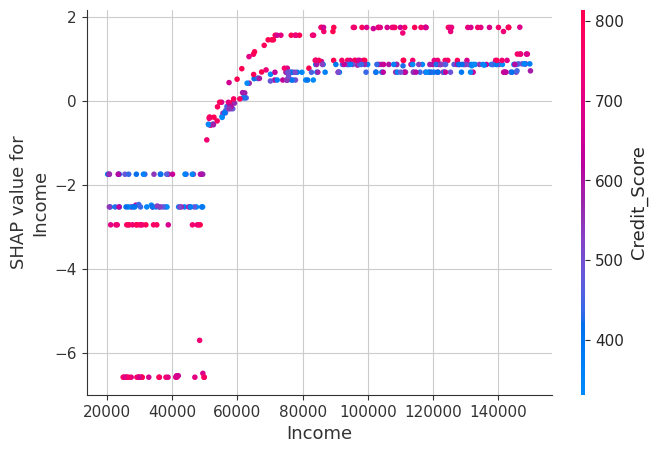

In [21]:
shap.dependence_plot(
    "Income",
    shap_values,
    X_test
)

SHAP Force Plot

In [22]:
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0]
)

Comparative Analysis Table

In [23]:
comparison_df = pd.DataFrame({
    "Filter_Method": feature_scores["Feature"].values[:10],
    "Embedded_Method": embedded_importance["Feature"].values[:10]
})

print(comparison_df)

       Filter_Method    Embedded_Method
0       Credit_Score       Credit_Score
1        Loan_Amount        Loan_Amount
2             Income             Income
3          Loan_Term                Age
4  Employment_Status          Loan_Term
5                Age  Employment_Status
